Imports


In [25]:
import pandas as pd
import numpy as np
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import roc_auc_score, f1_score, recall_score, average_precision_score


Load data & data cleaning

In [26]:
df = pd.read_csv("noshowappointments.csv")

df.head()
df.info()

df = df.drop(columns = ["PatientId", "AppointmentID"])

df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

df = df.rename(columns={"Hipertension": "Hypertension", 
                        "Handcap": "Handicap",
                        "SMS_received": "SMSReceived",
                        "No-show": "NoShow"})

df = df[(df["Age"] >= 0) & (df["Age"] <= 110)]

df["NoShow"] = df["NoShow"].map({"No": 0, "Yes": 1}).astype("int")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


Feature engineering

In [ ]:
mask = df["AppointmentDay"] < df["ScheduledDay"]
df.loc[mask, "AppointmentDay"] = df.loc[mask, "ScheduledDay"]


df["ScheduledWeekday"] = df["ScheduledDay"].dt.day_name()
df["AppointmentWeekday"] = df["AppointmentDay"].dt.day_name()
df["WaitingDays"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days


EDA

Ålder min/max/medel: 0 102 37.08569412147918
NoShow
0    0.798084
1    0.201916
Name: proportion, dtype: float64


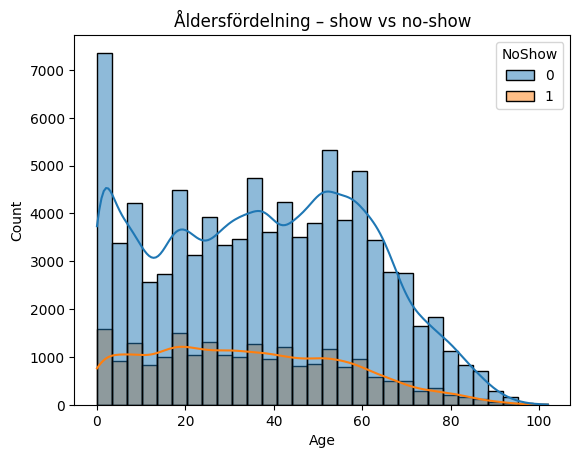

C:\Users\my\AppData\Local\Temp\ipykernel_7464\763966744.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["NoShow"].mean().plot(kind="bar")


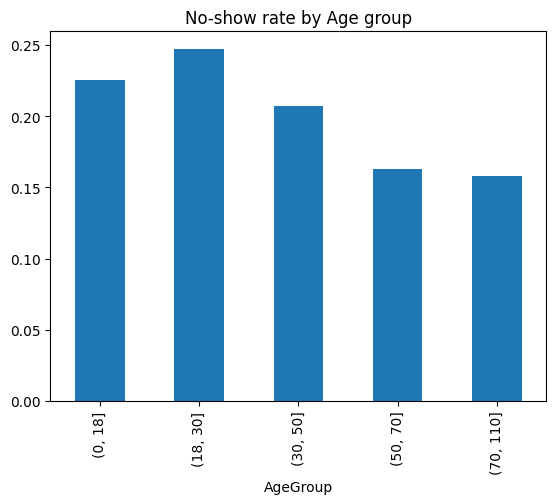

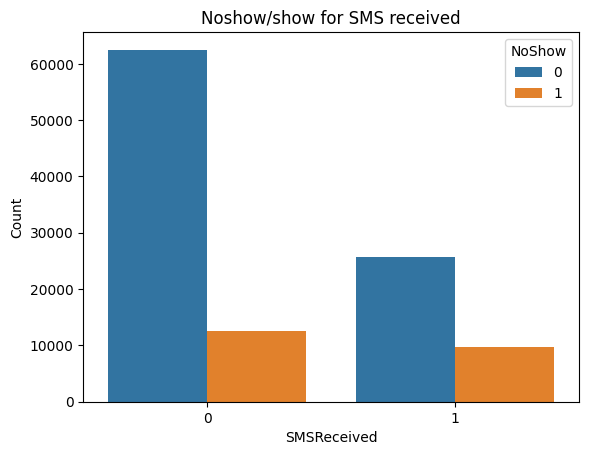

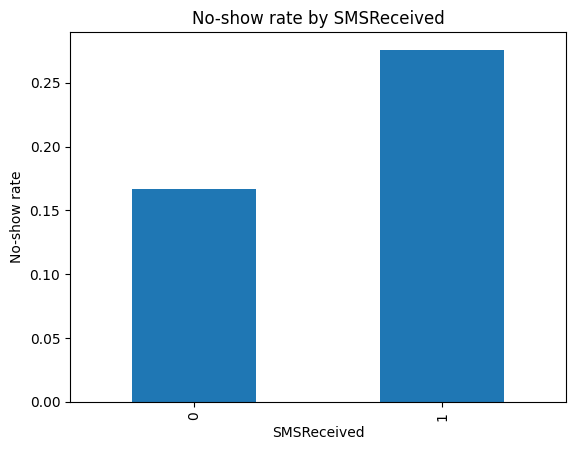

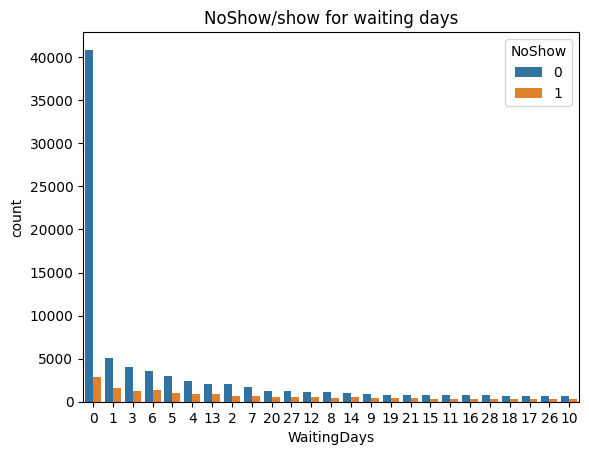

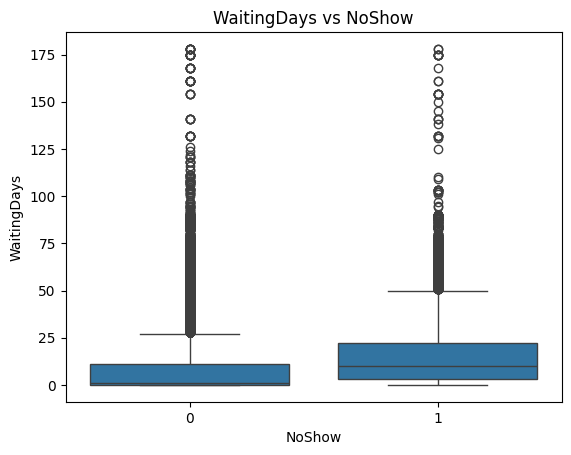

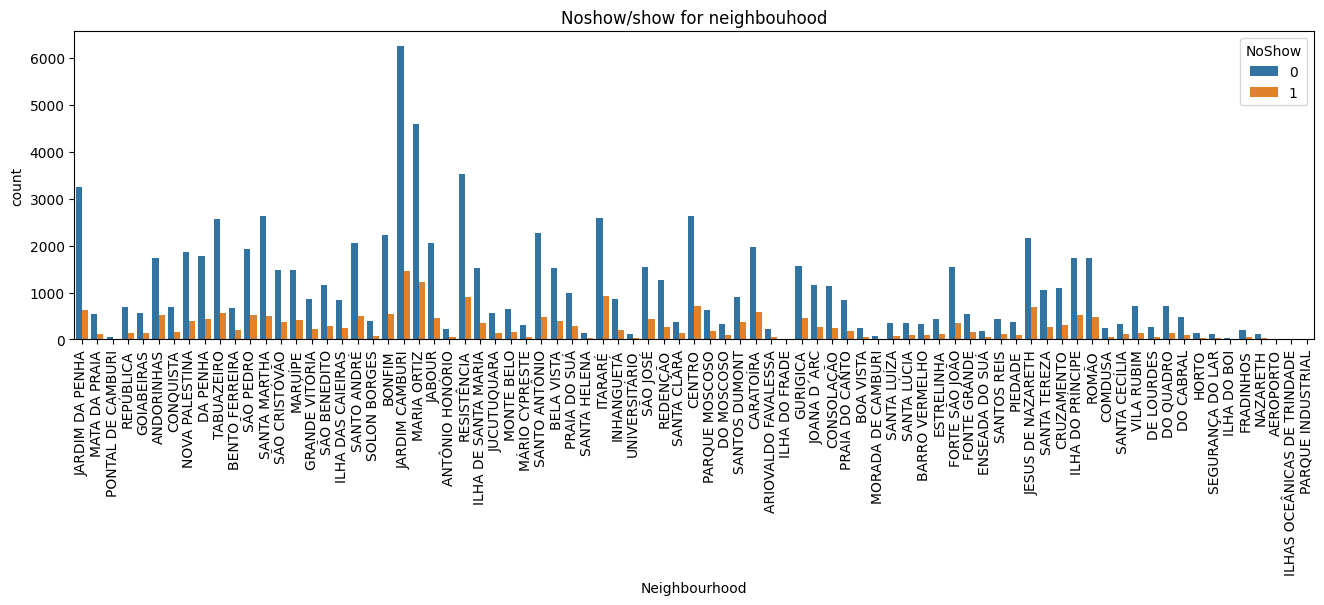

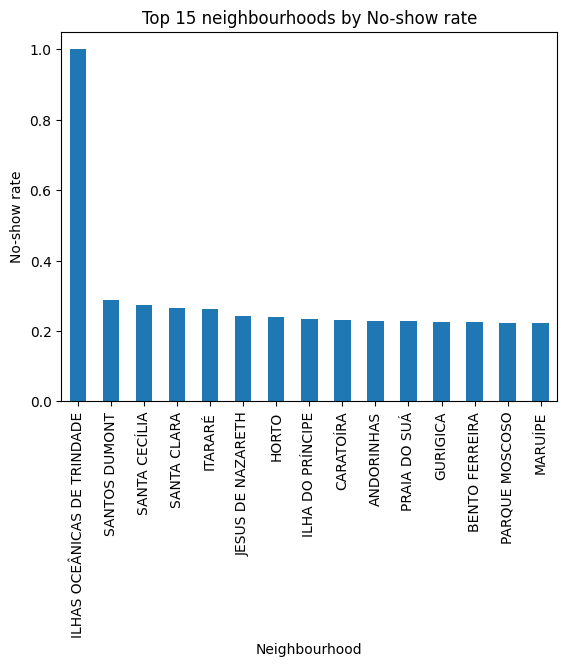

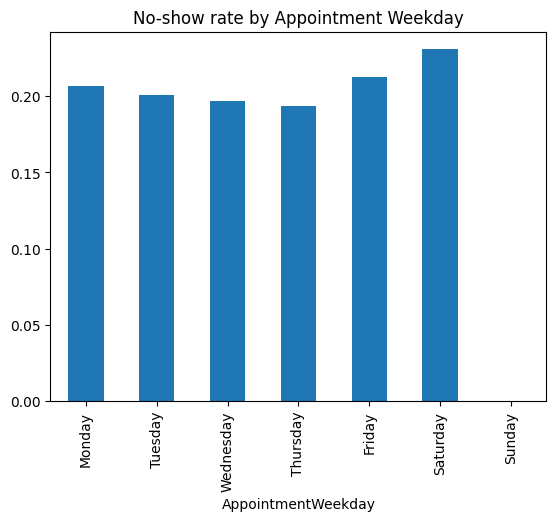

In [28]:
print("Ålder min/max/medel:", df['Age'].min(), df['Age'].max(), df["Age"].mean())

print(df['NoShow'].value_counts(normalize=True))
df["NoShow"].value_counts()

sns.histplot(data=df, x="Age", hue="NoShow", bins=30, kde=True)
plt.title("Åldersfördelning – show vs no-show")
plt.show()

df["AgeGroup"] = pd.cut(df["Age"], bins=[0,18,30,50,70,110])
df.groupby("AgeGroup")["NoShow"].mean().plot(kind="bar")
plt.title("No-show rate by Age group")
plt.show()

sns.countplot(data=df, x="SMSReceived", hue="NoShow")
plt.xlabel("SMSReceived")
plt.ylabel("Count")
plt.title("Noshow/show for SMS received")
plt.show()

df.groupby("SMSReceived")["NoShow"].mean().plot(kind="bar")
plt.title("No-show rate by SMSReceived")
plt.ylabel("No-show rate")
plt.show()

sns.countplot(x=df.WaitingDays, hue=df.NoShow, order=df.WaitingDays.value_counts().iloc[:25].index)
plt.title("NoShow/show for waiting days")
plt.show()

sns.boxplot(x="NoShow", y="WaitingDays", data=df)
plt.title("WaitingDays vs NoShow")
plt.show()

plt.figure(figsize=(16, 4))
sns.countplot(x=df.Neighbourhood, hue=df.NoShow)
plt.xticks(rotation=90)
plt.title("Noshow/show for neighbouhood")
plt.show()

df.groupby("Neighbourhood")["NoShow"].mean().sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Top 15 neighbourhoods by No-show rate")
plt.ylabel("No-show rate")
plt.show()

week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df.groupby("AppointmentWeekday")["NoShow"].mean().reindex(week).plot(kind="bar")
plt.title("No-show rate by Appointment Weekday")
plt.show()


Train/validation/test split 

In [29]:
X = df.drop("NoShow", axis=1)
y = df["NoShow"]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)


Defining models 

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

Model 1

In [31]:
#Features
numeric_columns = ["Age", "WaitingDays"]
cat_columns = ["Gender", "Neighbourhood", "ScheduledWeekday", "AppointmentWeekday"]

#Pipeline
preprocessor = ColumnTransformer(
    transformers = [("numeric", StandardScaler(), numeric_columns),
                    ("categorical", OneHotEncoder(handle_unknown="ignore"), cat_columns)])

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)                      
    ])

#Baseline results
results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_val_pred = pipe.predict(X_val)
    y_val_prob = pipe.predict_proba(X_val)[:, 1]
    
    roc = roc_auc_score(y_val, y_val_prob)
    pr_auc = average_precision_score(y_val, y_val_prob)
    f1 = f1_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    
    results[name] = {"ROC-AUC": roc, "F1": f1, "Recall": recall, "PR-AUC": pr_auc}
    
    print(f"{name} - ROC-AUC: {roc:.4f}, F1: {f1:.4f}, Recall: {recall:.4f}, PR-AUC: {pr_auc:.4f}")
    


Logistic Regression - ROC-AUC: 0.6574, F1: 0.0273, Recall: 0.0143, PR-AUC: 0.3083
Random Forest - ROC-AUC: 0.7174, F1: 0.3061, Recall: 0.2498, PR-AUC: 0.3598
XGBoost - ROC-AUC: 0.7381, F1: 0.1102, Recall: 0.0616, PR-AUC: 0.3760


Hyperparameter tuning & Threshold optimizing

In [32]:
param_grid = {"model__n_estimators": [100, 200], 
              "model__max_depth": [3, 5, 7],
              "model__learning_rate": [0.01, 0.1]}

grid_search = GridSearchCV(pipelines["XGBoost"], param_grid, cv=3, scoring="roc_auc")
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

#Tuning results
y_val_pred = best_model.predict(X_val)
y_val_prob = best_model.predict_proba(X_val)[:,1]

roc = roc_auc_score(y_val, y_val_prob)
pr_auc = average_precision_score(y_val, y_val_prob)
f1 = f1_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
print(f"Tuned XGBoost - ROC-AUC: {roc:.4f}, PR-AUC: {pr_auc:.4f} F1: {f1:.4f}, Recall: {recall:.4f}")

#Threshold
thresholds = np.linspace(0, 1, 100)
results_thr = []
for t in thresholds:
    y_pred_t = (y_val_prob >= t).astype(int)
    
    f1 = f1_score(y_val, y_pred_t)
    recall = recall_score(y_val, y_pred_t)
    

    results_thr.append((t, f1, recall))

df_thr = pd.DataFrame(results_thr, columns=["threshold", "f1", "recall"])
best_row_F1 = df_thr.loc[df_thr["f1"].idxmax()]
print(best_row_F1)

filtered = df_thr[df_thr["f1"] >= 0.8 * df_thr["f1"].max()]
best_row_recall = filtered.loc[filtered["recall"].idxmax()]
print(best_row_recall)

chosen_t = best_row_recall["threshold"]

#Threshold results
y_val_pred_thr = (y_val_prob >= chosen_t).astype(int)
f1 = f1_score(y_val, y_val_pred_thr)
recall = recall_score(y_val, y_val_pred_thr)
print(f"Threshold: {chosen_t}")
print(f"F1: {f1:.4f}")
print(f"Recall: {recall:.4f}")

Tuned XGBoost - ROC-AUC: 0.7420, PR-AUC: 0.3803 F1: 0.0492, Recall: 0.0258
threshold    0.212121
f1           0.451555
recall       0.774573
Name: 21, dtype: float64
threshold    0.040404
f1           0.377170
recall       0.982638
Name: 4, dtype: float64
Threshold: 0.04040404040404041
F1: 0.3772
Recall: 0.9826


Final training

In [33]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_model.fit(X_train_full, y_train_full)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['Age', 'WaitingDays']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Neighbourhood',
                                                   'ScheduledWeekday',
                                                   'AppointmentWeekday'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=Non...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

Final evaluation 

In [34]:
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= chosen_t).astype(int)


roc_test = roc_auc_score(y_test, y_test_prob)
pr_auc_test = average_precision_score(y_test, y_test_prob)
f1_test = f1_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)

print(f"Test ROC-AUC: {roc_test:.4f}")
print(f"Test PR-AUC: {pr_auc_test:.4f}")
print(f"Test F1: {f1_test:.4f}")
print(f"Test Recall: {recall_test:.4f}")

Test ROC-AUC: 0.7335
Test PR-AUC: 0.3696
Test F1: 0.3736
Test Recall: 0.9852


Feature importance

In [35]:
one_hot_encode = best_model.named_steps["preprocessor"].named_transformers_["categorical"]
cat_features = one_hot_encode.get_feature_names_out(cat_columns)

all_features = numeric_columns + list(cat_features)

importances = best_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance_df.head(10))

#Grouping
feature_importance_df["feature_group"] = feature_importance_df["feature"].apply(lambda x: x.split("_")[0])
feature_grouped = feature_importance_df.groupby("feature_group")["importance"].sum().sort_values(ascending=False)
print(feature_grouped)

                            feature  importance
1                       WaitingDays    0.072422
86          ScheduledWeekday_Monday    0.024415
89         ScheduledWeekday_Tuesday    0.022521
74      Neighbourhood_SANTOS DUMONT    0.018828
44  Neighbourhood_JESUS DE NAZARETH    0.018567
26       Neighbourhood_FONTE GRANDE    0.018422
12             Neighbourhood_BONFIM    0.018224
91        AppointmentWeekday_Friday    0.018076
31           Neighbourhood_GURIGICA    0.017257
43    Neighbourhood_JARDIM DA PENHA    0.016064
feature_group
Neighbourhood         0.761940
ScheduledWeekday      0.078975
WaitingDays           0.072422
AppointmentWeekday    0.068013
Age                   0.011102
Gender                0.007547
Name: importance, dtype: float32


Modell 2

In [36]:
#Features
binary_columns = ["Scholarship", "Hypertension", "Diabetes", "Alcoholism", "Handicap", "SMSReceived"]

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), cat_columns),
        ("binary", "passthrough", binary_columns)
    ]
)

pipelines_v2 = {}

for name, model in models.items():
    pipelines_v2[name] = Pipeline([
        ("preprocessor", preprocessor_v2),
        ("model", model)
    ])

#Baseline results
results_v2 = {}

for name, pipe in pipelines_v2.items():
    pipe.fit(X_train, y_train)

    y_val_pred_v2 = pipe.predict(X_val)
    y_val_prob_v2 = pipe.predict_proba(X_val)[:, 1]

    roc_v2 = roc_auc_score(y_val, y_val_prob_v2)
    pr_auc_v2 = average_precision_score(y_val, y_val_prob_v2)
    f1_v2 = f1_score(y_val, y_val_pred_v2)
    recall_v2 = recall_score(y_val, y_val_pred_v2)

    results_v2[name] = {
        "ROC-AUC": roc_v2,
        "F1": f1_v2,
        "Recall": recall_v2,
        "PR-AUC": pr_auc_v2
    }

    print(f"[V2] {name} - ROC-AUC: {roc_v2:.4f}, F1: {f1_v2:.4f}, Recall: {recall_v2:.4f}, PR-AUC: {pr_auc_v2:.4f}")
    

[V2] Logistic Regression - ROC-AUC: 0.6662, F1: 0.0242, Recall: 0.0126, PR-AUC: 0.3058
[V2] Random Forest - ROC-AUC: 0.7215, F1: 0.2582, Recall: 0.1907, PR-AUC: 0.3616
[V2] XGBoost - ROC-AUC: 0.7442, F1: 0.1278, Recall: 0.0722, PR-AUC: 0.3920


Hyperparameter och Threshold optimizing

In [37]:
grid_search_v2 = GridSearchCV(
    pipelines_v2["XGBoost"],
    param_grid,
    cv=3,
    scoring="roc_auc"
)

grid_search_v2.fit(X_train, y_train)

best_model_v2 = grid_search_v2.best_estimator_

#Tuning results
y_val_pred_v2 = best_model_v2.predict(X_val)
y_val_prob_v2 = best_model_v2.predict_proba(X_val)[:, 1]

roc_tuned_v2 = roc_auc_score(y_val, y_val_prob_v2)
pr_auc_tuned_v2 = average_precision_score(y_val, y_val_prob_v2)
f1_tuned_v2 = f1_score(y_val, y_val_pred_v2)
recall_tuned_v2 = recall_score(y_val, y_val_pred_v2)

print(f"V2 Tuned XGBoost - ROC-AUC: {roc_tuned_v2:.4f}, PR-AUC: {pr_auc_tuned_v2:.4f}, F1: {f1_tuned_v2:.4f}, Recall: {recall_tuned_v2:.4f}")

#Threshold
thresholds = np.linspace(0, 1, 100)
results_thr_v2 = []

for t in thresholds:
    y_pred_t_v2 = (y_val_prob_v2 >= t).astype(int)

    f1_thr_v2 = f1_score(y_val, y_pred_t_v2)
    recall_thr_v2 = recall_score(y_val, y_pred_t_v2)

    results_thr_v2.append((t, f1_thr_v2, recall_thr_v2))

df_thr_v2 = pd.DataFrame(results_thr_v2, columns=["threshold", "f1", "recall"])

best_row_v2 = df_thr_v2.loc[df_thr_v2["f1"].idxmax()]
print(best_row_v2)
filtered_v2 = df_thr_v2[df_thr_v2["f1"] >= 0.8 * df_thr_v2["f1"].max()]
best_row_recall_v2 = filtered_v2.loc[filtered_v2["recall"].idxmax()]
print(best_row_recall_v2)

chosen_t_v2 = best_row_recall_v2["threshold"]

#Threshold result
y_val_pred_thr_v2 = (y_val_prob_v2 >= chosen_t_v2).astype(int)

f1_v2_thr = f1_score(y_val, y_val_pred_thr_v2)
recall_v2_thr = recall_score(y_val, y_val_pred_thr_v2)

print(f"Threshold V2: {chosen_t_v2}")
print(f"F1 V2: {f1_v2_thr:.4f}")
print(f"Recall V2: {recall_v2_thr:.4f}")

V2 Tuned XGBoost - ROC-AUC: 0.7465, PR-AUC: 0.3988, F1: 0.0678, Recall: 0.0358
threshold    0.212121
f1           0.456781
recall       0.767292
Name: 21, dtype: float64
threshold    0.040404
f1           0.381243
recall       0.981238
Name: 4, dtype: float64
Threshold V2: 0.04040404040404041
F1 V2: 0.3812
Recall V2: 0.9812


Final training

In [38]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_model_v2.fit(X_train_full, y_train_full)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['Age', 'WaitingDays']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Neighbourhood',
                                                   'ScheduledWeekday',
                                                   'AppointmentWeekday']),
                                                 ('binary', 'passthrough',
                                                  ['Scholarship',
                                                   'Hypertension', 'Diabetes',
                                                   'Alcoholism', 'Handicap',
                                                   'SMSReceived'])])),
                ('mod...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=7, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

Final evaluation

In [39]:
y_test_prob_v2 = best_model_v2.predict_proba(X_test)[:, 1]
y_test_pred_v2 = (y_test_prob_v2 >= chosen_t_v2).astype(int)

roc_test_v2 = roc_auc_score(y_test, y_test_prob_v2)
pr_auc_test_v2 = average_precision_score(y_test, y_test_prob_v2)
f1_test_v2 = f1_score(y_test, y_test_pred_v2)
recall_test_v2 = recall_score(y_test, y_test_pred_v2)

print(f"[V2 TEST] ROC-AUC: {roc_test_v2:.4f}")
print(f"[V2 TEST] PR-AUC: {pr_auc_test_v2:.4f}")
print(f"[V2 TEST] F1: {f1_test_v2:.4f}")
print(f"[V2 TEST] Recall: {recall_test_v2:.4f}")

[V2 TEST] ROC-AUC: 0.7379
[V2 TEST] PR-AUC: 0.3845
[V2 TEST] F1: 0.3774
[V2 TEST] Recall: 0.9814


Feature importance

In [40]:
one_hot_encode_v2 = best_model_v2.named_steps["preprocessor"].named_transformers_["categorical"]
cat_features_v2 = one_hot_encode_v2.get_feature_names_out(cat_columns)

all_features_v2 = numeric_columns + list(cat_features_v2) + binary_columns

importances_v2 = best_model_v2.named_steps["model"].feature_importances_

feature_importance_df_v2 = pd.DataFrame({
    "feature": all_features_v2,
    "importance": importances_v2
}).sort_values(by="importance", ascending=False)

print(feature_importance_df_v2.head(10))

feature_importance_df_v2["feature_group"] = feature_importance_df_v2["feature"].apply(
    lambda x: x.split("_")[0]
)

feature_grouped_v2 = feature_importance_df_v2.groupby("feature_group")["importance"].sum().sort_values(ascending=False)

print(feature_grouped_v2)

                            feature  importance
1                       WaitingDays    0.073679
86          ScheduledWeekday_Monday    0.023861
89         ScheduledWeekday_Tuesday    0.020823
74      Neighbourhood_SANTOS DUMONT    0.018001
91        AppointmentWeekday_Friday    0.017545
31           Neighbourhood_GURIGICA    0.016192
92        AppointmentWeekday_Monday    0.014938
71       Neighbourhood_SANTA TEREZA    0.014897
80           Neighbourhood_SÃO JOSÉ    0.014831
44  Neighbourhood_JESUS DE NAZARETH    0.014771
feature_group
Neighbourhood         0.708385
ScheduledWeekday      0.076303
WaitingDays           0.073679
AppointmentWeekday    0.065565
SMSReceived           0.014088
Handicap              0.012148
Age                   0.011286
Alcoholism            0.010202
Scholarship           0.008737
Gender                0.007116
Hypertension          0.006622
Diabetes              0.005868
Name: importance, dtype: float32
